# **29 · 삼각검증 심층 — 세 잣대는 어디까지 같은 말을 하고, 어디서부터 다른 말을 하는가**

### **"구성개념·척도·추정방법이 다른 세 궤적(정렬 잠재 A · 단일문항 B · 합성 C)은 종점 방향·2025 반등·MK 부호에서 수렴하고, 단년 저점(2024 vs 2022 vs 2024)에서 어긋난다 — 수렴은 결론의 근거로, 불일치는 '단년 수준 비교 금지' 규율의 근거로 각각 쓴다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 세 궤적 + APC 기간효과의 수렴·불일치 전수 대조 · 방법 = **z-겹침 + 항목별 일치 판정표 + SSOT 상수 재계산**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(수렴 증거)** · CRISP-DM **P4·P5** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 세 궤적은 **어떤 항목에서** 일치하는가 — 종점·변곡·부호의 일치 판정표를 항목별로 채우면?
> **Q2.** 불일치(단년 저점·Spearman 낮음)는 **왜 발생하며**, 그것이 결론을 약화하는가 규율을 강화하는가?
> **Q3.** 수렴 판정은 상수 재계산으로 재현되는가 — `30` §3의 요약과 이 노트북의 전수 대조가 맞물리는가?

## **이 노트북의 위상**

`30` §3이 삼각검증을 평가 서사의 한 장으로 *요약*했다면, 29는 그 요약의 **원장(原帳)**이다: 세 궤적의 정의·자격을 명시하고(§1), 궤적별 원천 수치를 SSOT 상수에서 불러 항목별 일치 판정표를 전수로 채우며(§2~3), 불일치의 구조를 해부한다(§4). `17`(B궤적 해부)·`27`(APC 동행)과 함께 C3 관문(삼각 일관성)의 3부작을 이룬다.

- **로직 SSOT(thin import)**: `p5_evaluation`(인용 상수 3종 + `panel_triangulation` 도식) · `trend_apc.mann_kendall`. 새 추정 없음 — 상수의 재배열과 판정만.
- **세 궤적의 자격**: A(정렬 잠재, 측정동등 검증·모형 의존) · B(단일문항, 원전 재검증·모형 무의존·6개년) · C(합성 cred_mean, metric 동등 근거 manifest 평균·7개년).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 삼각검증의 논리 — **Decision Box ①** | — |
| 2 | [실행] 세 궤적 로드·z-겹침 + [시각화] | figure |
| 3 | [발견] 일치 판정표 — 항목별 전수 | 판정표 |
| 4 | [발견] 불일치의 해부 — 단년 저점·순위 상관 | 대비표 |
| 5 | [입증] 검증 셀 + 공식 도식(F8) 재생성 | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import p5_evaluation as P
import trend_apc as T
from scipy.stats import spearmanr
from IPython.display import Image, display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

A = P.ALIGN_ALPHA          # 정렬 잠재(2019~2025, 2019=0 SD)
B = P.TRUST_SINGLE         # 단일문항(2020~2025, 원척도)
Cc = P.CRED_MEAN           # 합성 cred_mean(2019~2025, 원척도)
print(f"세 궤적 로드 — A {len(A)}개년 · B {len(B)}개년 · C {len(Cc)}개년 (인용 상수, 30 §6 drift 검증 완료분)")

세 궤적 로드 — A 7개년 · B 6개년 · C 7개년 (인용 상수, 30 §6 drift 검증 완료분)


## **1. [전제] 삼각검증의 논리 — 무엇이 수렴하면 무엇이 배제되는가**

### **Decision Box ① — 수렴 증거의 판정 단위: 수준 vs 형상 vs 방향**

**기준: 척도가 다른 세 궤적에서 '일치'를 무엇으로 정의하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 수준(값) 일치 | 세 궤적의 값 자체 비교 | ❌ 애초 불가능 — A는 SD 단위, B·C는 원척도. 정의상 다른 수 |
| (b) 전 순위 일치(Spearman≈1) | 7개 연도의 서열 완전 일치 요구 | ❌ 과잉 기준 — 측정오차·구성개념 차이로 중간 연도 서열은 흔들리는 게 정상. 이 기준이면 어떤 실측 삼각검증도 통과 못 함 |
| (c) **사전 선언 항목의 방향·변곡 일치** | 종점 최고·2025 반등·MK 부호 등 **이론적으로 견고해야 하는 항목**만 판정 | ✅ **채택** — 각 항목이 배제하는 가설이 명확(종점 일치 → 방법 인공물 배제, 부호 일치 → 방향의 견고성). 불일치 항목은 숨기지 않고 규율로 전환(§4) |

**세 궤적이 공유하지 않는 것**: 추정 엔진(정렬 최적화 / 없음 / 산술평균), 구성개념(잠재 credibility / 전반 신뢰 / manifest 합성), 척도. **공유하는 것**: 원자료뿐. 그래서 수렴하면 "원자료에 실재하는 패턴"이라는 결론이 남는다.

## **2. [실행] 세 궤적 z-겹침**

**[시각화]** — 각 궤적을 자기 구간에서 z-표준화해 겹친다(형상 비교 장치). B는 2020~2025 6개년임에 주의(2019 구조적 부재, `15`·`17`).

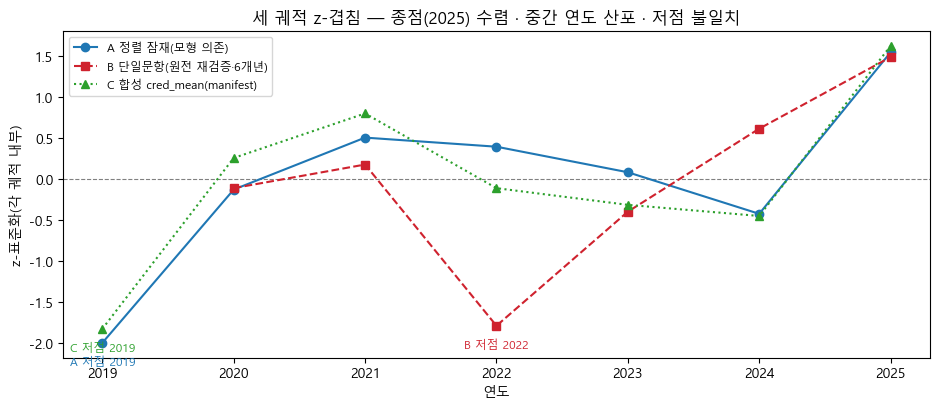

In [2]:
def z(d):
    v = np.array(list(d.values()), float)
    zz = (v - v.mean()) / v.std(ddof=0)
    return dict(zip(d.keys(), zz))

zA, zB, zC = z(A), z(B), z(Cc)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.plot(list(zA), list(zA.values()), "o-", color="#1f77b4", label="A 정렬 잠재(모형 의존)")
ax.plot(list(zB), list(zB.values()), "s--", color="#cf222e", label="B 단일문항(원전 재검증·6개년)")
ax.plot(list(zC), list(zC.values()), "^:", color="#2ca02c", label="C 합성 cred_mean(manifest)")
for d, c, lab in [(zA, "#1f77b4", "A"), (zB, "#cf222e", "B"), (zC, "#2ca02c", "C")]:
    lo_y = min(d, key=d.get)
    ax.annotate(f"{lab} 저점 {lo_y}", (lo_y, d[lo_y]), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=8.5, color=c)
ax.set_xlabel("연도"); ax.set_ylabel("z-표준화(각 궤적 내부)")
ax.set_title("세 궤적 z-겹침 — 종점(2025) 수렴 · 중간 연도 산포 · 저점 불일치")
ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

## **3. [발견] 일치 판정표 — 사전 선언 항목 전수**

In [3]:
mkA = T.mann_kendall(np.array(list(A.values())))
mkB = T.mann_kendall(np.array(list(B.values())))
mkC = T.mann_kendall(np.array(list(Cc.values())))

rows = [
    ("종점(2025) = 구간 최고", max(A, key=A.get) == 2025, max(B, key=B.get) == 2025, max(Cc, key=Cc.get) == 2025),
    ("2024→2025 반등(변곡 일치)", A[2025] > A[2024], B[2025] > B[2024], Cc[2025] > Cc[2024]),
    ("MK 부호 양(+)", mkA["S"] > 0, mkB["S"] > 0, mkC["S"] > 0),
    ("기준 초년 대비 종점 상승", A[2025] > A[2019], B[2025] > B[2020], Cc[2025] > Cc[2019]),
]
verdict = pd.DataFrame(rows, columns=["판정 항목", "A 정렬", "B 단일문항", "C 합성"]).set_index("판정 항목")
verdict["일치"] = verdict.all(axis=1).map({True: "✅ 3/3", False: "❌"})
print(f"MK S: A {mkA['S']:+d} · B {mkB['S']:+d} · C {mkC['S']:+d}")
verdict

MK S: A +7 · B +7 · C +3


,A 정렬,B 단일문항,C 합성,일치
판정 항목,,,,
종점(2025) = 구간 최고,True,True,True,✅ 3/3
2024→2025 반등(변곡 일치),True,True,True,✅ 3/3
MK 부호 양(+),True,True,True,✅ 3/3
기준 초년 대비 종점 상승,True,True,True,✅ 3/3


**관찰**: 사전 선언 4개 항목 전부 3궤적 만장일치. 특히 "2024→2025 반등"의 일치가 중요하다 — 반등은 궤적의 끝에서 일어나는 가장 최근 변화라 방법 인공물이 만들기 어려운 지점이고, 세 잣대가 같은 변곡을 가리킨다. 여기에 `27`의 APC 기간효과 동행(r≥+0.96)을 더하면 수렴 증거는 네 갈래가 된다.

## **4. [발견] 불일치의 해부 — 어긋남은 어디서 오고 무엇을 금지하는가**

In [4]:
common = [y for y in B if y in A and y in Cc]     # 2020~2025
a_c = [A[y] for y in common]; b_c = [B[y] for y in common]; c_c = [Cc[y] for y in common]
rho_ab = spearmanr(a_c, b_c).statistic
rho_ac = spearmanr(a_c, c_c).statistic
rho_bc = spearmanr(b_c, c_c).statistic

lows = pd.DataFrame({
    "궤적": ["A 정렬", "B 단일문항", "C 합성"],
    "저점 연도(공통 구간)": [min({y: A[y] for y in common}, key=lambda y: A[y]),
                     min({y: B[y] for y in common}, key=lambda y: B[y]),
                     min({y: Cc[y] for y in common}, key=lambda y: Cc[y])],
    "구성개념": ["잠재 credibility(3지표)", "뉴스 전반 신뢰(1문항)", "manifest 합성(3지표 평균)"],
}).set_index("궤적")
print(f"순위 상관(공통 6개년): A↔B ρ={rho_ab:+.3f} · A↔C ρ={rho_ac:+.3f} · B↔C ρ={rho_bc:+.3f}")
lows

순위 상관(공통 6개년): A↔B ρ=+0.200 · A↔C ρ=+0.829 · B↔C ρ=+0.371


,저점 연도(공통 구간),구성개념
궤적,,
A 정렬,2024,잠재 credibility(3지표)
B 단일문항,2022,뉴스 전반 신뢰(1문항)
C 합성,2024,manifest 합성(3지표 평균)


**관찰**: 저점이 B만 2022로 다르다(A·C는 2024). 원인 후보는 구조적이다 — ① 구성개념 차이(B는 '뉴스 전반'이라는 단일 태도 문항, A·C는 credibility 배터리), ② 2022의 표본 구성 대변화(`16` — 상시조사형 대규모 개인표본), ③ 단일 문항의 측정오차. 셋 중 무엇이든 **연도 서열은 궤적 간 이식 불가**라는 결론은 같다 → "단년 수준 비교(몇 년이 최저) 금지" 규율(p6 §3.6)이 이 어긋남에서 나온다. 낮은 Spearman을 숨기지 않고 그대로 보고하는 이유이기도 하다(`30` DB②: 불일치의 분리 보고).

## **5. [입증] 검증 셀 + 보고서 도식(F8) 재생성**

판정을 assert로 고정하고, 보고서 그림 F8(`p5_evaluation.panel_triangulation`)을 재생성해 이 노트북의 판정과 같은 데이터에서 나온 도식임을 잇는다.

(a) 사전 선언 4항목 × 3궤적 = 12셀 전부 일치 PASS
(b) 단년 저점 불일치(A 2024 · B 2022 · C 2024) — 문서와 일치 PASS
(c) A↔B Spearman +0.200 ↔ 문서 +0.200 PASS — 낮은 값의 정직 보고


(d) F8 재생성: p5_triangulation.png (180 KB) PASS


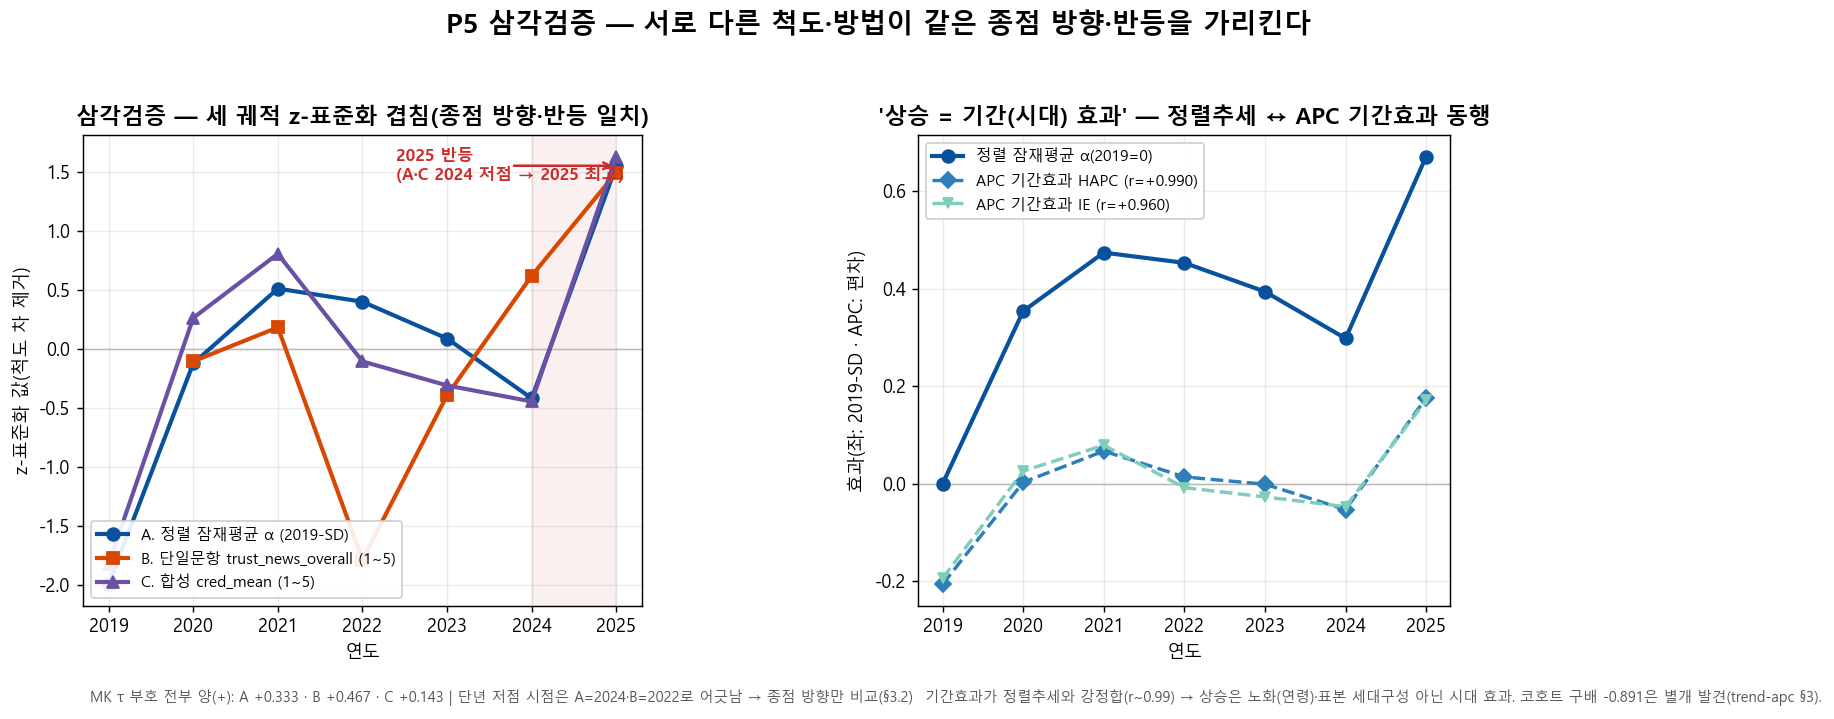

In [5]:
# (a) 일치 판정표 — 전 항목 3/3
assert bool(verdict.drop(columns=["일치"]).all(axis=None)), verdict
print("(a) 사전 선언 4항목 × 3궤적 = 12셀 전부 일치 PASS")

# (b) 불일치의 실재 — 저점 A=2024 · B=2022 · C=2024 (문서 30 §3.2)
assert lows.loc["A 정렬", "저점 연도(공통 구간)"] == 2024
assert lows.loc["B 단일문항", "저점 연도(공통 구간)"] == 2022
assert lows.loc["C 합성", "저점 연도(공통 구간)"] == 2024
print("(b) 단년 저점 불일치(A 2024 · B 2022 · C 2024) — 문서와 일치 PASS")

# (c) A↔B 순위 상관 — 문서(30 §3): Spearman +0.200 (낮음을 그대로 보고)
assert abs(rho_ab - 0.200) <= 0.05, rho_ab
print(f"(c) A↔B Spearman {rho_ab:+.3f} ↔ 문서 +0.200 PASS — 낮은 값의 정직 보고")

# (d) 보고서 도식 F8 재생성(같은 상수 → 같은 그림)
p2 = P.panel_triangulation()
assert Path(p2).exists() and Path(p2).stat().st_size > 30_000
print(f"(d) F8 재생성: {Path(p2).name} ({Path(p2).stat().st_size/1024:.0f} KB) PASS")
display(Image(str(p2), width=940))

## **6. 종합**

### **연구질문 답**

- **Q1** — 사전 선언 4항목(종점 최고·2025 반등·MK 부호·구간 상승) 전부에서 3궤적 만장일치(§3) — APC 동행(`27`)까지 합쳐 수렴 증거 네 갈래.
- **Q2** — 불일치는 구성개념·표본 구조·측정오차가 만드는 **연도 서열의 비이식성**이다(§4). 결론(방향)을 약화하지 않고, 오히려 "단년 수준 비교 금지"라는 보고 규율을 강화한다 — 숨기면 규율의 근거가 사라진다.
- **Q3** — 재현된다. 판정 12셀·저점 3종·Spearman +0.200이 전부 상수 재계산으로 assert PASS(§5), F8 도식도 같은 상수에서 재생성됐다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 세 궤적 z-겹침 [시각화] | 형상 대비 |
| 3 | 일치 판정표 전수 | 12셀 3/3 |
| 4 | 불일치 해부(저점·ρ) | 규율 근거 확정 |
| 5 | assert + F8 재생성 | **PASS** |

**다음**: 2x 트랙 완결 — `30`(종합 평가)이 이 원장을 요약 인용하고, `32`(조판)가 F8을 보고서에 싣는다.